**1.Problem Definition**

***Problem Statement***

Brain tumors are among the most serious neurological diseases and require accurate diagnosis for effective treatment. Magnetic Resonance Imaging (MRI) is commonly used by medical professionals to detect and identify different types of brain tumors. However, manually examining MRI scans can be time-consuming and depends on the expertise of radiologists.

***Project Objective***

The objective of this project is to develop an image classification system that automatically classifies brain MRI images into one of four categories:

Glioma Tumor, Meningioma Tumor, Pituitary Tumor, No Tumor

The project compares the performance of Machine Learning models Random Forest+SVC and a Deep Learning model (Multi-Layer Perceptron - MLP) to determine which model provides better classification accuracy.

**2.Dataset Selection**

***Dataset Source***

Kaggle Dataset: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri

***Features***

Each MRI image acts as the input feature.

***Target Variable***

The target variable is the brain tumor class.

In [5]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [6]:
train_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"
test_path = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing"

In [7]:
classes = sorted(os.listdir(train_path))

print("Classes:")
print(classes)

Classes:
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [8]:
train_count = []

for c in classes:

    folder = os.path.join(train_path, c)

    train_count.append(len(os.listdir(folder)))

df = pd.DataFrame({
    "Class": classes,
    "Training Images": train_count
})

df

,Class,Training Images
0,glioma_tumor,826
1,meningioma_tumor,822
2,no_tumor,395
3,pituitary_tumor,827


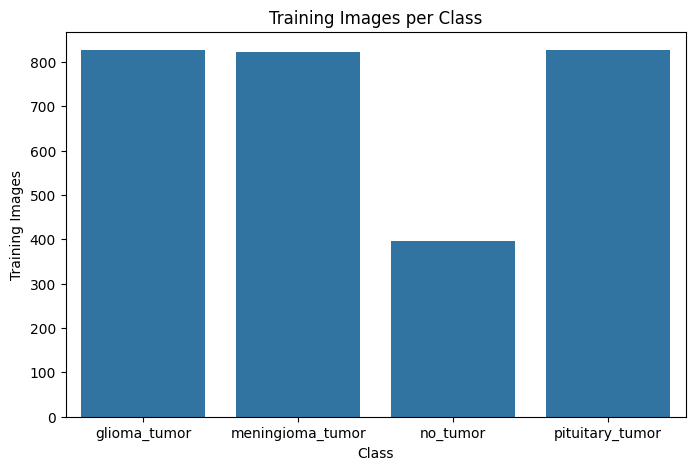

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Class",
    y="Training Images",
    data=df
)

plt.title("Training Images per Class")
plt.show()

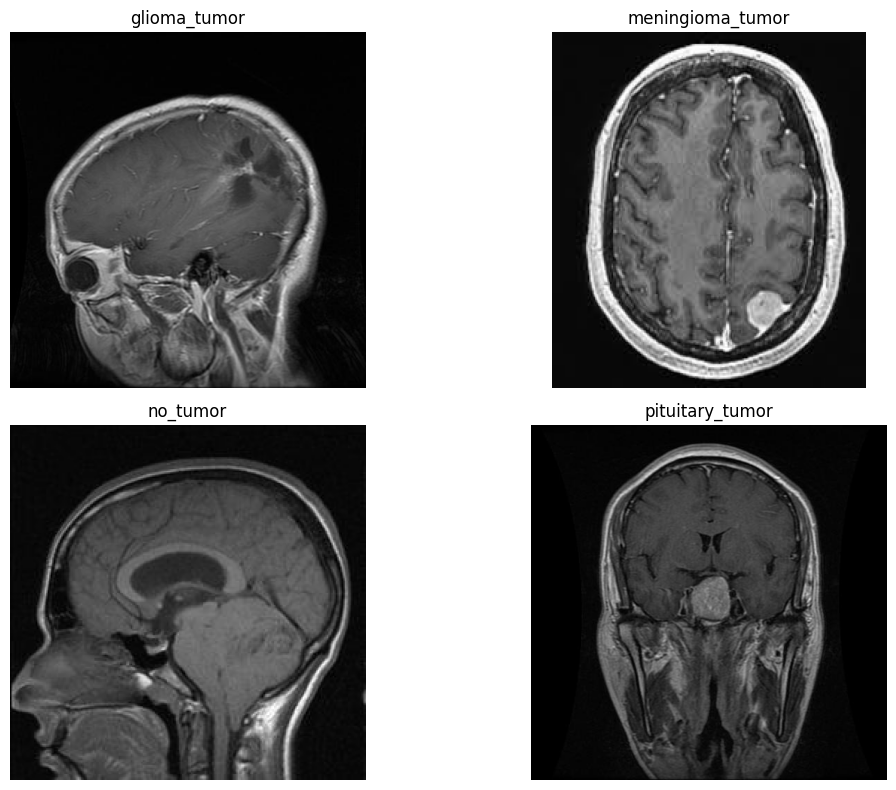

In [10]:
from PIL import Image
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    img_name = os.listdir(os.path.join(train_path, cls))[0]

    img_path = os.path.join(train_path, cls, img_name)

    img = Image.open(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
sizes = []

for c in classes:

    folder = os.path.join(train_path, c)

    image_name = os.listdir(folder)[0]

    path = os.path.join(folder, image_name)

    img = cv2.imread(path)

    sizes.append(img.shape)

sizes

[(512, 512, 3), (239, 211, 3), (236, 236, 3), (512, 512, 3)]

In [12]:
df.describe()

,Training Images
count,4.000000
mean,717.500000
std,215.010852
min,395.000000
25%,715.250000
50%,824.000000
75%,826.250000
max,827.000000


In [13]:
df.duplicated().sum()

np.int64(0)

In [15]:
IMG_SIZE=64
X = []
y = []

for cls in classes:

    folder = os.path.join(train_path, cls)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        img = cv2.imread(img_path)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)

        y.append(cls)

In [16]:
X = np.array(X)
y = np.array(y)

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

Images Shape: (2870, 64, 64, 3)
Labels Shape: (2870,)


In [17]:
X = X / 255.0
print("Minimum Pixel:", X.min())
print("Maximum Pixel:", X.max())

Minimum Pixel: 0.0
Maximum Pixel: 1.0


In [19]:
def load_dataset(path):
    X = []
    y = []

    classes = os.listdir(path)

    for cls in classes:
        folder = os.path.join(path, cls)

        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)

            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            X.append(img)
            y.append(cls)

    return np.array(X), np.array(y)

In [20]:
X_train, y_train = load_dataset(train_path)

print(X_train.shape)
print(y_train.shape)

(2870, 64, 64)
(2870,)


In [21]:
X_test, y_test = load_dataset(test_path)

print(X_test.shape)
print(y_test.shape)

(394, 64, 64)
(394,)


In [22]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)

y_test = encoder.transform(y_test)

print(encoder.classes_)

['glioma_tumor' 'meningioma_tumor' 'no_tumor' 'pituitary_tumor']


In [24]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(X_train.shape)
print(X_test.shape)

(2870, 4096)
(394, 4096)


In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [26]:
from sklearn.svm import SVC
svm = SVC( kernel='rbf')
svm.fit(X_train, y_train)

SVC()

In [27]:
from sklearn.metrics import accuracy_score

y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("Test Accuracy:", acc_svm)

Test Accuracy: 0.6624365482233503


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred_svm, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_svm, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_svm, average="weighted"))

Precision: 0.7121026575046171
Recall   : 0.6624365482233503
F1 Score : 0.6238322773641137


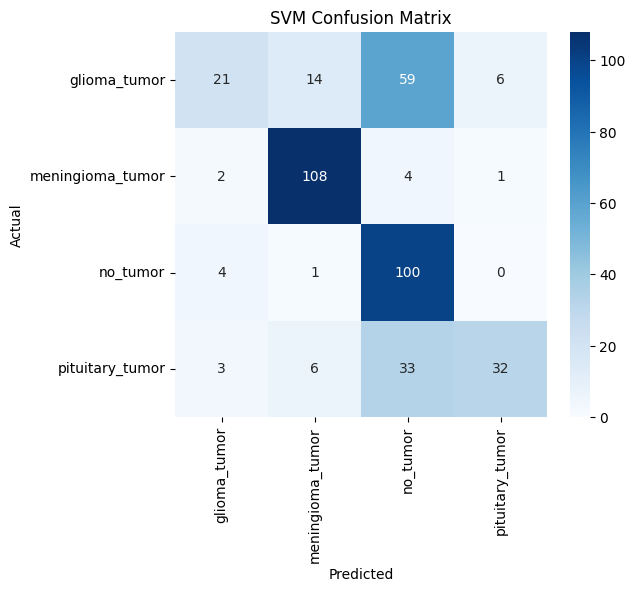

In [45]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [30]:
from sklearn.metrics import accuracy_score
y_pred_rf= rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Test Accuracy:", acc_rf)

Test Accuracy: 0.7030456852791879


In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_rf, average="weighted"))

Precision: 0.8052836541599331
Recall   : 0.7030456852791879
F1 Score : 0.6560725452766659


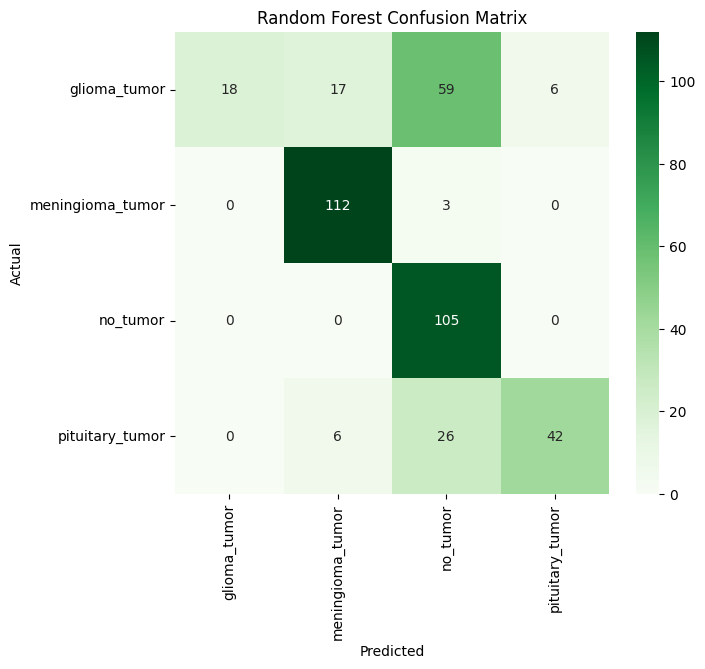

In [44]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Greens",
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [32]:
print(X.shape)
print(X_train.shape)

(2870, 64, 64, 3)
(2870, 4096)


In [37]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
deep_model = Sequential([
    Dense(128, activation="relu", input_shape=(4096,)),
    Dense(64, activation="relu"),
    Dense(4, activation="softmax")
])

deep_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,932 (2.03 MB)

 Trainable params: 532,932 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
deep_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
history_deep = deep_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7365 - loss: 0.8042 - val_accuracy: 0.4251 - val_loss: 1.3744
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9238 - loss: 0.2330 - val_accuracy: 0.7491 - val_loss: 0.7139
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9560 - loss: 0.1499 - val_accuracy: 0.7561 - val_loss: 0.7673
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9878 - loss: 0.0545 - val_accuracy: 0.7038 - val_loss: 0.9804
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9948 - loss: 0.0315 - val_accuracy: 0.6237 - val_loss: 1.3585
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9970 - loss: 0.0166 - val_accuracy: 0.7125 - val_loss: 1.0782
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9895 - loss: 0.0320 - val_accuracy: 0.6916 - val_loss: 1.3744
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9983 - loss: 0.0089 - val_accuracy: 0.6742 - val_loss

In [40]:
deep_loss, deep_acc = deep_model.evaluate(
    X_test,
    y_test
)

print("Deep Accuracy:", deep_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7183 - loss: 3.9212
Deep Accuracy: 0.7182741165161133


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


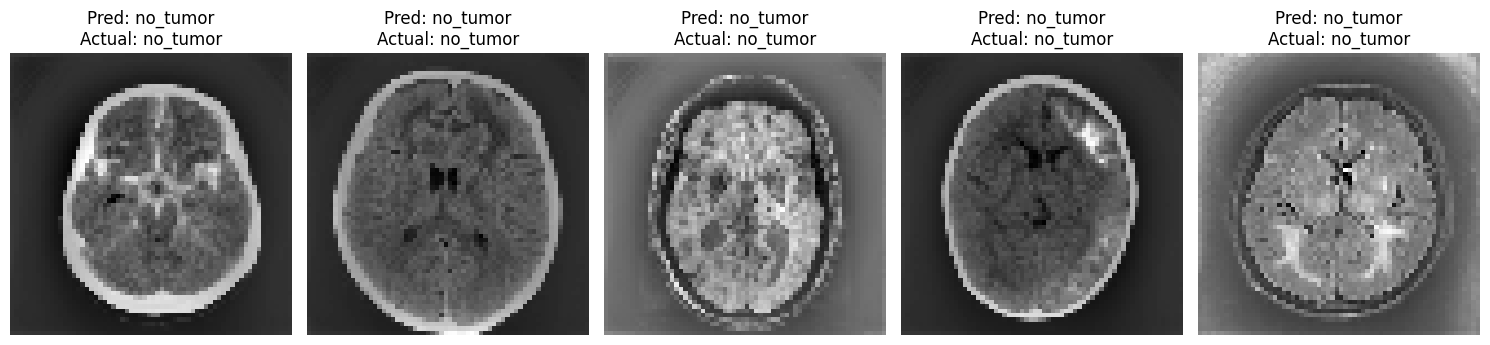

In [46]:
import matplotlib.pyplot as plt
import numpy as np

y_pred_deep = np.argmax(deep_model.predict(X_test), axis=1)

class_names = encoder.classes_

plt.figure(figsize=(15, 8))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i].reshape(64, 64), cmap="gray")
    plt.axis("off")
    plt.title(
        f"Pred: {class_names[y_pred_deep[i]]}\n"
        f"Actual: {class_names[y_test[i]]}"
    )

plt.tight_layout()
plt.show()

In [47]:
joblib.dump(svm,"brain_tumor_svm.pkl")

joblib.dump(scaler,"scaler.pkl")

joblib.dump(encoder,"label_encoder.pkl")

deep_model.save("brain_tumor_mlp.keras")
print("Files Saved Successfully")

Files Saved Successfully
